In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=sns.load_dataset("titanic")
print("Dataset loaded successfully!")
print("Shape:",df.shape)


Dataset loaded successfully!
Shape: (891, 15)


In [4]:
import os

os.makedirs("analytics", exist_ok=True)

print("analytics folder created")

analytics folder created


In [5]:
df.to_csv("analytics/titanic.csv",index=False)
print("Titanic dataset saved")

Titanic dataset saved


In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [8]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.shape

(891, 15)

In [10]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [11]:
missing=df.isnull().sum()
print(missing)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [12]:
missing_percent=df.isnull().mean()*100
print(missing_percent)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [13]:
missing_table=pd.DataFrame({
    "missing_count":df.isnull().sum(),
    "missing_percent":df.isnull().mean()*100
})
missing_table=missing_table[
    missing_table["missing_count"]>0
]
missing_table

,missing_count,missing_percent
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


In [14]:
df["age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

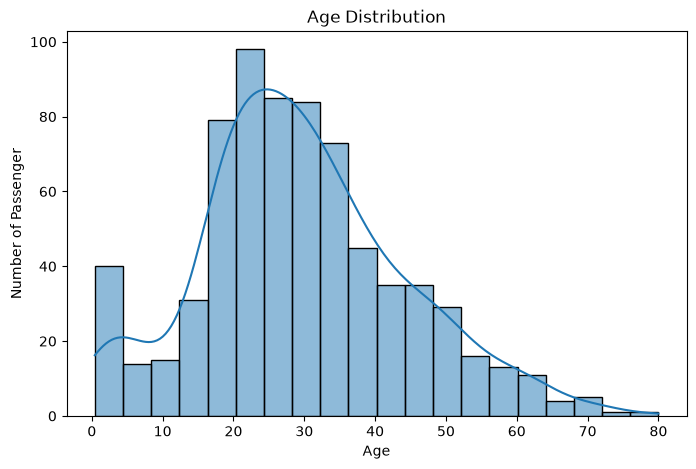

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"].dropna(),kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passenger")
plt.show()

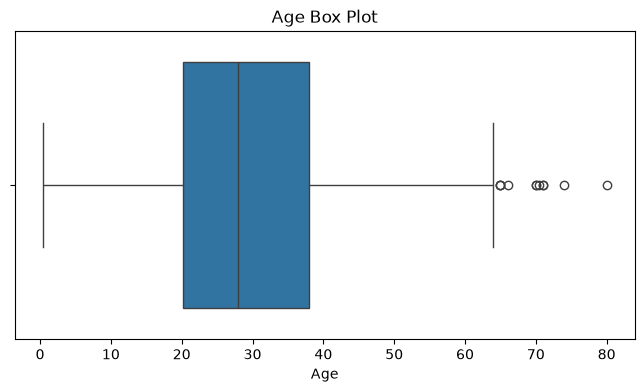

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["age"])
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()

In [17]:
Q1=df["age"].quantile(0.25)
Q3=df["age"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
higher=Q3+1.5*IQR
age_outliers=df[
    (df["age"]<lower)|
    (df["age"]>higher)
]
print("Lower bound:",lower)
print("Higher bound:",higher)
print("Number of age outliers:",len(age_outliers))


Lower bound: -6.6875
Higher bound: 64.8125
Number of age outliers: 11


In [18]:
df["fare"].describe()


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

In [19]:
print("Mean:",df["fare"].mean())
print("Median:",df["fare"].median())
print("Mode:",df["fare"].mode()[0])

Mean: 32.204207968574636
Median: 14.4542
Mode: 8.05


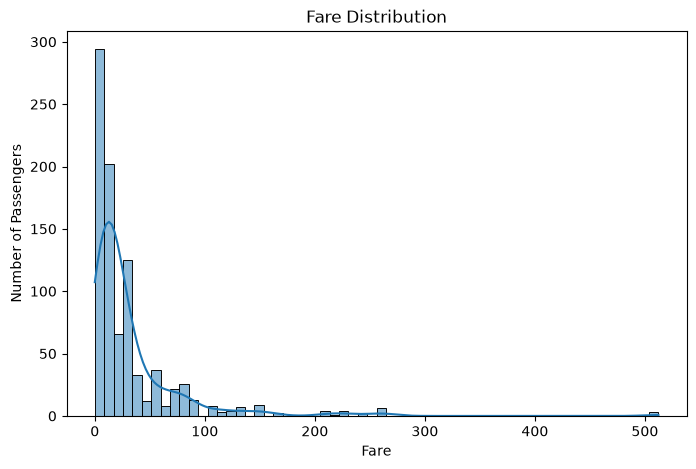

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["fare"],kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

In [21]:
print("Fare skewwness:",df["fare"].skew())

Fare skewwness: 4.787316519674893


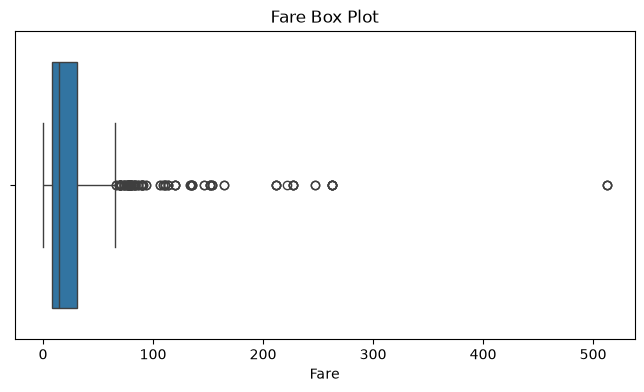

In [22]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["fare"])
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()

In [23]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

fare_outliers = df[
    (df["fare"] < lower) |
    (df["fare"] > upper)
]

print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of fare outliers:", len(fare_outliers))

Lower bound: -26.724
Upper bound: 65.6344
Number of fare outliers: 116


Did survival differ between males and females?

In [25]:
survival_by_sex=df.groupby("sex")["survived"].mean()
print(survival_by_sex)
print(survival_by_sex*100)

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


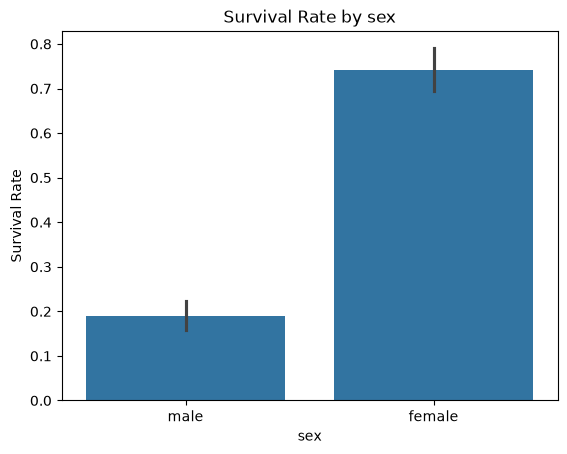

In [26]:
sns.barplot(data=df,x="sex",y="survived")
plt.title("Survival Rate by sex")
plt.ylabel("Survival Rate")
plt.show()

In [28]:
survival_by_class=df.groupby("pclass")["survived"].mean()
print(survival_by_class)
print(survival_by_class*100)

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64
pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


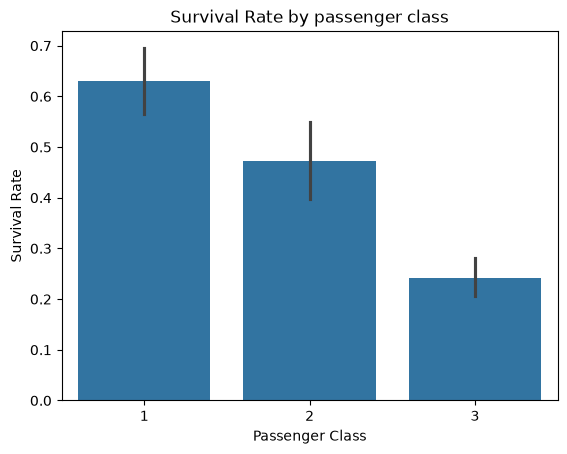

In [29]:
sns.barplot(data=df,x="pclass",y="survived")
plt.title("Survival Rate by passenger class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

In [31]:
survival_sex_class=df.groupby(
    ["sex","pclass"]
)["survived"].mean()
print(survival_sex_class)

sex     pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


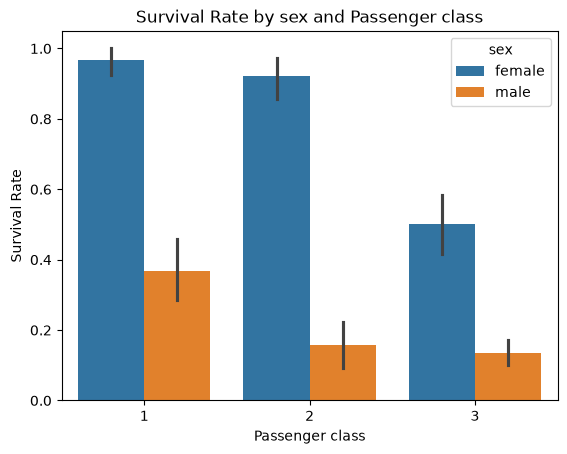

In [32]:
sns.barplot(
    data=df,x="pclass",
    y="survived",
    hue="sex"
)
plt.title("Survival Rate by sex and Passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Survival Rate")
plt.show()

In [33]:
corr_columns=[
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]
corr=df[corr_columns].corr()
print(corr)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500
age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067
sibsp    -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000


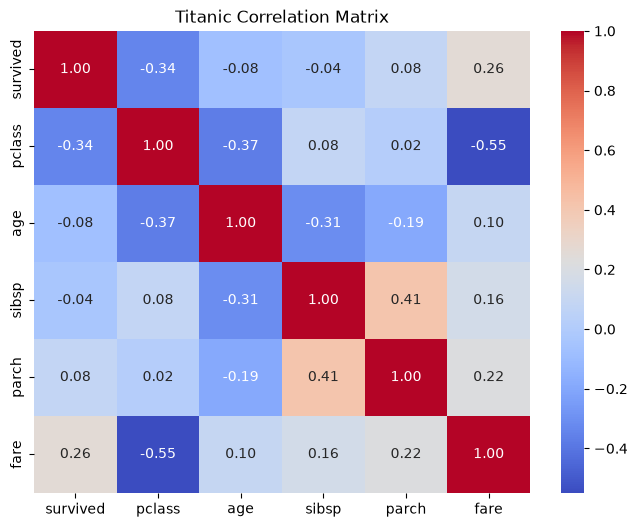

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Titanic Correlation Matrix")
plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df[["age_scaled","fare_scaled"]]=scaler.fit_transform(
    df[["age","fare"]]
)
print(df[["age_scaled","fare_scaled"]].describe())

         age_scaled   fare_scaled
count  7.140000e+02  8.910000e+02
mean   2.388379e-16  3.987333e-18
std    1.000701e+00  1.000562e+00
min   -2.016979e+00 -6.484217e-01
25%   -6.595416e-01 -4.891482e-01
50%   -1.170488e-01 -3.573909e-01
75%    5.718310e-01 -2.424635e-02
max    3.465126e+00  9.667167e+00
